In [83]:
import pandas as pd 
df_tracking = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv').set_index('frame')
# print(df_tracking)
print(df_tracking.index.unique().sort_values())

# df_tracking = df_tracking.sort_values(by='frame')
# print(df_tracking)
# frame_1_df = df_tracking[df_tracking['frame'] == 1]
# print(frame_1_df)



Int64Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,
                9,
            ...
            35056, 35057, 35058, 35059, 35060, 35061, 35062, 35063, 35064,
            35065],
           dtype='int64', name='frame', length=35066)


In [10]:
import pandas as pd
import dask.dataframe as dd
print("Pandas version:", pd.__version__)
print("Dask version:", dd.__version__)

Pandas version: 1.3.5


AttributeError: module 'dask.dataframe' has no attribute '__version__'

In [79]:
# def reshape_tracking_csv(df): 
#     pivoted_df = pd.DataFrame() 
#     for frame in df.index.unique():  
#        frame_data = df.loc[frame] 
#        frame_dict = dict() 
       
#        for _, obj in frame_data.iterrows(): 
#            obj_name = obj['name']
#            frame_dict[obj_name] = obj['name']
#            frame_dict[f'{obj_name}_x'] = obj['x']
#            frame_dict[f'{obj_name}_y'] = obj['y']
#            frame_dict[f'{obj_name}_w'] = obj['w']
#            frame_dict[f'{obj_name}_h'] = obj['h']
#        pivoted_df = pivoted_df.append(pd.Series(frame_dict, name=frame))
#     return pivoted_df

# reshaped_df = reshape_tracking_csv(df_tracking)
# print(reshaped_df)
#this takes too long 


KeyboardInterrupt: 

In [9]:
#Rescale the coordinates of the label csv to 1280x720 

import pandas as pd
import os 
# Read the CSV file
def change_resolution(file_path):
    df = pd.read_csv(file_path)
    scale_factor = 4/3 #scale factor from 960x540 to 1280x720
    coordinate_columns = ['xmin', 'ymin', 'xmax', 'ymax']
    df[coordinate_columns] = (df[coordinate_columns] * scale_factor).astype(int)

    df['width'] = 1280
    df['height'] = 720
    print(df)
    return df 
# Save the transformed coordinates
# for file in os.listdir(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy'):
#     df = change_resolution(os.path.join(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy', file))
#     df.to_csv(os.path.join(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\data\ground_truth_labels_copy', file), index=False)
# # df.to_csv('data/ground_truth_labels/1.2.3_C1_labels.csv', index=False)

               filename  width  height         class  xmin  ymin  xmax  ymax  \
0    1.2.3_C1_00001.png   1280     720        helmet    34   360   112   421   
1    1.2.3_C1_00001.png   1280     720  spray bottle   221   310   253   360   
2    1.2.3_C1_00001.png   1280     720   paper towel   266   285   296   362   
3    1.2.3_C1_00001.png   1280     720          step   721   501   916   576   
4    1.2.3_C1_00001.png   1280     720      dumbbell   869   341   921   368   
..                  ...    ...     ...           ...   ...   ...   ...   ...   
553  1.2.3_C1_00059.png   1280     720   granola bar   469   344   498   365   
554  1.2.3_C1_00059.png   1280     720    flower pot   160   333   213   392   
555  1.2.3_C1_00059.png   1280     720      dumbbell   888   341   938   362   
556  1.2.3_C1_00059.png   1280     720      dumbbell   936   341   992   365   
557  1.2.3_C1_00059.png   1280     720     jump rope   514   344   568   366   

     index  
0        5  
1        5  


In [1]:
import pandas as pd 
import pickle as pkl 
import numpy as np

with open(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\resources\gen_sim_glove_50.pkl', 'rb') as f: 
    glove_vectors = pkl.load(f)
tracking_csv_1 = r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv'
tracking_df_1 = pd.read_csv(tracking_csv_1)
tracking_df_1['frame'] = tracking_df_1['frame'] + 1 
# unique_frames = list((tracking_df_1['frame'] + 1).unique())
frames = np.sort(tracking_df_1['frame'].unique())
print(frames)
print(tracking_df_1['frame'])

[    1     2     3 ... 35064 35065 35066]
0           195
1           196
2           197
3           198
4           199
          ...  
376124    35062
376125    35063
376126    35064
376127    35065
376128    35066
Name: frame, Length: 376129, dtype: int64


In [24]:
def check_obj_per_frame(frame): 
    track_df = tracking_df_1[tracking_df_1['frame']==frame]
    print(track_df)

for frame in range(1500,3000): 
    check_obj_per_frame(frame)

       frame           name      x      y      w     h  confidence  \
8497    1500    flower pot0  173.0  309.0   51.0  51.0         1.0   
9097    1500      dumbbell0  869.0  341.0   52.0  27.0         1.0   
9697    1500      dumbbell1  916.0  338.0   54.0  26.0         1.0   
10297   1500          step0  721.0  501.0  195.0  75.0         1.0   
10897   1500        helmet0   34.0  360.0   78.0  61.0         1.0   
12096   1500  spray bottle2  221.0  310.0   32.0  50.0         1.0   
12696   1500   paper towel0  266.0  285.0   30.0  77.0         1.0   
13895   1500   sport drink0  496.0  308.0   21.0  56.0         1.0   

       ground_truth  width  height  
8497              1   1280     720  
9097              1   1280     720  
9697              1   1280     720  
10297             1   1280     720  
10897             1   1280     720  
12096             1   1280     720  
12696             1   1280     720  
13895             1   1280     720  
       frame           name         

In [21]:
tracking_df_1 = tracking_df_1.sort_values(by='frame')
tracking_df_1_frame_1 = tracking_df_1[tracking_df_1['frame'] == 50].copy() #will have to iterate over every frame 
#need to put .copy() since i am modifying the copy and not the view 

emb_dim = glove_vectors['apple'].size
# tracking_df_1_frame_1.loc[:,'name'] = tracking_df_1_frame_1.loc[:, 'name'].apply(lambda x: "".join([char for char in x if not char.isdigit()]))
print(tracking_df_1_frame_1)



      frame           name           x           y           w          h  \
1360     50  spray bottle0   31.026708  359.117444   87.734976  65.591193   
758      50          step0  715.453674  503.792100  206.582613  66.234714   
156      50      dumbbell0  868.593980  339.318986   49.816265  28.705723   
1059     50        helmet0   38.022307  363.150661   75.095715  53.998599   
1661     50   paper towel0   37.495186  361.141148   76.482764  61.336902   
457      50      dumbbell1  911.590399  340.481686   59.480430  25.891945   

      confidence  ground_truth  width  height  
1360    0.853910             1   1280     720  
758     0.999957             1   1280     720  
156     0.997076             1   1280     720  
1059    0.999371             1   1280     720  
1661    0.991667             1   1280     720  
457     0.999957             1   1280     720  


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import dask.dataframe as dd 

sample_eye = dd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\all_eye_080422.csv").compute()
print(sample_eye)

         frame      video      x      y      sub
0            1  1.2.3.mp4  638.3  360.5  e159001
1            1  1.2.3.mp4  638.0  360.4  e159001
2            1  1.2.3.mp4  637.8  360.4  e159001
3            1  1.2.3.mp4  637.6  360.5  e159001
4            1  1.2.3.mp4  637.1  360.5  e159001
...        ...        ...    ...    ...      ...
1633729  35119  3.1.3.mp4    NaN    NaN  e159100
1633730  35119  3.1.3.mp4    NaN    NaN  e159100
1633731  35119  3.1.3.mp4    NaN    NaN  e159100
1633732  35119  3.1.3.mp4    NaN    NaN  e159100
1633733  35119  3.1.3.mp4  236.0  404.8  e159100

[169559578 rows x 5 columns]


In [4]:
movie_data = sample_eye[sample_eye['video'] == '1.2.3.mp4']

In [5]:
frame_1 = movie_data[movie_data['frame']==1]
print(frame_1.groupby(['sub']).mean())

         frame           x           y
sub                                   
e159001    1.0  637.388235  360.494118
e159002    1.0  634.947059  342.082353
e159004    1.0  637.358824  372.541176
e159005    1.0  639.523529  373.252941
e159013    1.0  646.570588  370.888235
...        ...         ...         ...
e159096    1.0  620.415385  352.084615
e159097    1.0  635.600000  363.065217
e159098    1.0  647.677273  369.618182
e159099    1.0  640.360714  349.942857
e159100    1.0  640.194118  369.829412

[79 rows x 3 columns]


In [8]:
sample_eye_movie_1 = dd.read_csv(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\1.2.3_eye_080422.csv").compute()
print(sample_eye_movie_1)
unique_list = sample_eye_movie_1['frame'].unique().tolist()


         frame      video      x      y      sub
0            1  1.2.3.mp4  638.3  360.5  e159001
1            1  1.2.3.mp4  638.0  360.4  e159001
2            1  1.2.3.mp4  637.8  360.4  e159001
3            1  1.2.3.mp4  637.6  360.5  e159001
4            1  1.2.3.mp4  637.1  360.5  e159001
...        ...        ...    ...    ...      ...
1779087  35129  1.2.3.mp4    NaN    NaN  e159100
1779088  35129  1.2.3.mp4    NaN    NaN  e159100
1779089  35129  1.2.3.mp4    NaN    NaN  e159100
1779090  35129  1.2.3.mp4    NaN    NaN  e159100
1779091  35129  1.2.3.mp4  757.7 -629.3  e159100

[39244395 rows x 5 columns]


In [9]:
def GaussianMask(sizex, sizey, sigma=10, center=None, fix=1):
    """
    Generate a Gaussian mask.
    sizex  : mask width
    sizey  : mask height
    sigma  : Gaussian standard deviation
    center : Gaussian mean (center of the mask)
    fix    : Maximum value of the Gaussian function
    return : Gaussian mask as a 2D numpy array
    """
    x = np.arange(0, sizex, 1, float)
    # print(x)
    y = np.arange(0, sizey, 1, float)
    x, y = np.meshgrid(x, y) #creates a grid of x and y values 
    # print(y.shape)
    # print(y)
    if center is None:
        x0 = sizex // 2
        y0 = sizey // 2
    else:
        if not np.isnan(center[0]) and not np.isnan(center[1]):
            x0 = center[0]
            y0 = center[1]
        else:
            return np.zeros((sizey, sizex))
    gaussian_mask = fix * np.exp(-((x - x0) ** 2 / sigma ** 2 + (y - y0) ** 2 / sigma ** 2)) #2D gaussian filter 
    # print(gaussian_mask.shape)
    # print(gaussian_mask)
    return gaussian_mask


def Fixpos2Densemap(fix_arr, width, height):
    """
    Convert fixation positions to a density map.
    fix_arr : array of fixation data [number of subjects x 3(x,y,fixation)]
    width   : output image width
    height  : output image height
    return  : heatmap as a 2D numpy array
    """
    heatmap = np.zeros((height, width), np.float32)
    for n_subject in range(fix_arr.shape[0]):
        center = (fix_arr[n_subject][1], fix_arr[n_subject][2])
        place = GaussianMask(width, height, sigma=33, center=center)
        # print("Sum: ", np.sum(place))
        heatmap += place
    heatmap /= fix_arr.shape[0] 
    normalized_heatmap = heatmap / heatmap.sum()
 
    return (normalized_heatmap)*1000 #scale values by 1000 





In [22]:
frame_1 = sample_eye_movie_1[sample_eye_movie_1['frame'] == 50] 
avg_frame = frame_1.groupby(['sub']).mean()
values = avg_frame.to_numpy()
print(values)

width, height = 1280, 720

# Generate the heatmap
heatmap = Fixpos2Densemap(values, width, height)
print(heatmap)
print("overall heatmap sum", heatmap.sum())

[[  50.          620.85882353  367.47058824]
 [  50.          642.71176471  335.13529412]
 [  50.          496.76470588  346.92352941]
 [  50.          544.64705882  378.57647059]
 [  50.          700.56470588  500.69411765]
 [  50.          496.65882353  342.06470588]
 [  50.          206.02777778  365.87777778]
 [  50.          221.57647059  408.41764706]
 [  50.          892.85555556  350.29444444]
 [  50.          940.7625      407.11875   ]
 [  50.          897.28823529  390.08235294]
 [  50.          494.07647059  314.23529412]
 [  50.          278.95294118  347.51176471]
 [  50.          526.61176471  370.16470588]
 [  50.          921.08823529  389.49411765]
 [  50.          383.98125     525.85625   ]
 [  50.          906.41176471  338.34705882]
 [  50.          815.29411765  460.87058824]
 [  50.          861.48888889  341.77777778]
 [  50.          891.70625     328.45625   ]
 [  50.          416.025       526.1       ]
 [  50.          712.90588235  352.13529412]
 [  50.   

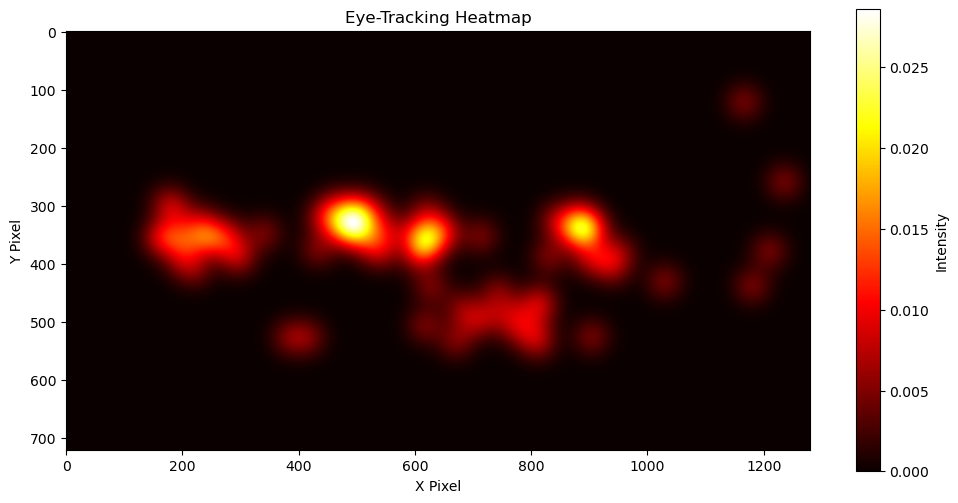

In [23]:
plt.figure(figsize=(12, 6))
plt.imshow(heatmap, cmap='hot')
plt.title('Eye-Tracking Heatmap')
plt.colorbar(label='Intensity')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

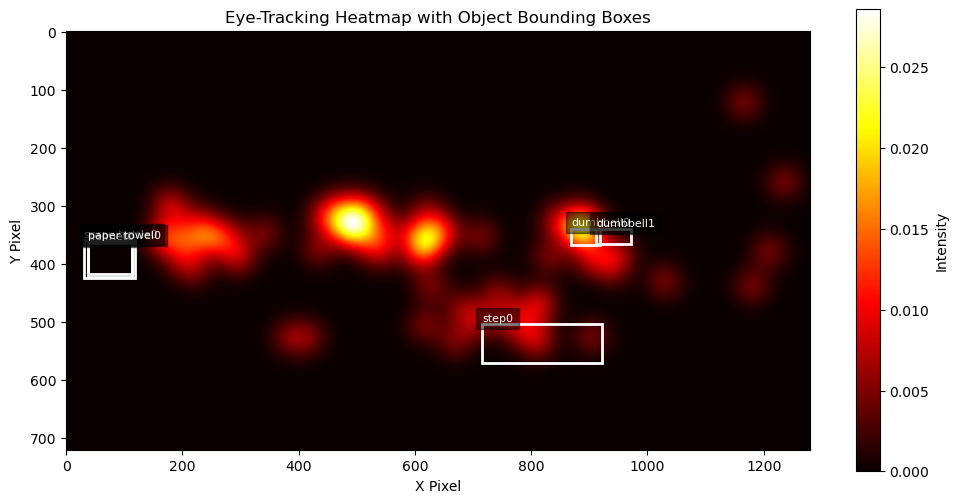

In [24]:
plt.figure(figsize=(12, 6))
plt.imshow(heatmap, cmap='hot')
plt.title('Eye-Tracking Heatmap with Object Bounding Boxes')
plt.colorbar(label='Intensity')


for _, obj in tracking_df_1_frame_1.iterrows():
    rect = plt.Rectangle((obj['x'], obj['y']), 
                        obj['w'],  # width
                        obj['h'],  # height
                        fill=False, edgecolor='white', linewidth=2)
    plt.gca().add_patch(rect)
    # Add object labels
    plt.text(obj['x'], obj['y']-5, obj['name'], 
             color='white', fontsize=8, 
             bbox=dict(facecolor='black', alpha=0.5))

plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()


In [31]:
def attention_weight(heatmap, tracking_df):
    attention_weights = dict()
    epsilon = 1e-6 #make sure the average is not 0 
    boxes = tracking_df_1_frame_1[['name', 'x', 'y', 'w', 'h']].values
    attention_weights = {
            row[0]: np.mean(heatmap[int(row[2]):int(row[2])+int(row[4]), 
                                      int(row[1]):int(row[1])+int(row[3])]) + epsilon
            for row in boxes
        }
    # total = sum(attention_weights.values())
    total = heatmap.sum()
    print(total)
    attention_weights = {k: v / total for k, v in attention_weights.items()}
    print(sum(attention_weights.values()))
    print(attention_weights.values())
    return attention_weights

attention_weights = attention_weight(heatmap, tracking_df_1_frame_1)
print(attention_weights)

1000.0002
2.6848581499901448e-05
dict_values([4.51925248210673e-08, 3.386104317464682e-06, 1.6976394135625197e-05, 3.189256786477381e-08, 3.0029719329827415e-08, 6.3789682347959035e-06])


In [32]:
print(glove_vectors['dumbbell']*attention_weights['dumbbell'])
print(glove_vectors['helmet']*attention_weights['helmet'])

KeyError: 'dumbbell'

In [61]:
import numpy as np

def get_emb(df, emb_dim, attention_weights): 
    average = np.zeros(shape=(1, emb_dim))
    for _, row in df.iterrows():
        r = np.zeros(shape=(1, emb_dim))
        try:
            r += glove_vectors[row['name']]
        except Exception as e:
            # if object not in glove, split into words
            words = row['name'].split(' ')
            for w in words:
                w = w.replace('(', '').replace(')', '')
                r += glove_vectors[w]
            r /= len(words)
        # equal contribution from each object
        average += r * attention_weights[row['name']] #multiply by the attentional weight here
    return average / len(df) 

print(get_emb(tracking_df_1_frame_1, emb_dim, attention_weights))


[[-0.00717957 -0.00123235 -0.00113726 -0.00372283  0.00134811  0.00310391
  -0.00236065 -0.00584413  0.00154673 -0.00271167  0.00275536  0.0026059
   0.00106814  0.00231253  0.00117961  0.00280022 -0.00503169  0.00224204
  -0.00608655 -0.0120505  -0.00079187 -0.00030655  0.00033322 -0.00667036
  -0.0032921  -0.0103577  -0.00300852  0.01160225  0.00919104 -0.00559227
   0.01265684  0.00068051 -0.00600791  0.00533267 -0.00344365  0.00789964
   0.00503508  0.00273505  0.00516394 -0.00126069  0.00761167  0.00257372
  -0.00119837  0.00508455  0.0037407  -0.0006494   0.00123553 -0.00295795
   0.00364618 -0.00678178]]


In [47]:
import numpy as np

def get_emb(df, emb_dim): 
    average = np.zeros(shape=(1, emb_dim))
    for _, row in df.iterrows():
        r = np.zeros(shape=(1, emb_dim))
        try:
            r += glove_vectors[row['name']]
        except Exception as e:
            # if object not in glove, split into words
            words = row['name'].split(' ')
            for w in words:
                w = w.replace('(', '').replace(')', '')
                r += glove_vectors[w]
            r /= len(words)
        # equal contribution from each object
        average += r #multiply by the attentional weight here
    return average / len(df) 

print(get_emb(tracking_df_1_frame_1, emb_dim))

[[-0.28382416 -0.0045955  -0.20979783 -0.41331116  0.22721866  0.31037251
   0.45230023 -0.15986167  0.14456342 -0.01298666 -0.06806434  0.255996
   0.18631916  0.55724866 -0.154315    0.08497733 -0.30999834  0.24254417
  -0.15224741 -0.92987334  0.11762732 -0.32735543 -0.076015   -0.43871116
  -0.24445084 -0.82040501 -0.02167391  0.99822464  0.4997175  -0.63639485
   1.10353168  0.38416257 -0.64318584  0.65770668 -0.18776149  0.53953666
   0.46823016  0.20148334  0.28551749 -0.21889548  0.42600917  0.1398975
  -0.35257084  0.36289566 -0.05950033 -0.13435155  0.44144749  0.05992251
   0.24445767 -0.39373166]]


In [6]:
import numpy as np
obj_handling_emb = np.full(shape=(1, 100), fill_value=np.nan)
print(obj_handling_emb)
obj_handling_embs = np.zeros(shape=(0, 100))
print(obj_handling_embs)

obj_handling_embs = np.vstack([obj_handling_embs, obj_handling_emb])
print(obj_handling_embs)



[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan]]
[]
[[nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
  nan nan nan nan nan nan nan nan nan nan]]


In [13]:
import pandas as pd
import numpy as np
import dask.dataframe as dd 
from pandas import DataFrame
# from src.utils import parse_config
import os 

def GaussianMask(sizex, sizey, sigma=10, center=None, fix=1):
    """
    Generate a Gaussian mask.
    sizex  : mask width
    sizey  : mask height
    sigma  : Gaussian standard deviation
    center : Gaussian mean (center of the mask)
    fix    : Maximum value of the Gaussian function
    return : Gaussian mask as a 2D numpy array
    """
    x = np.arange(0, sizex, 1, float)
    y = np.arange(0, sizey, 1, float)
    x, y = np.meshgrid(x, y)
    if center is None:
        x0 = sizex // 2
        y0 = sizey // 2
    else:
        if not np.isnan(center[0]) and not np.isnan(center[1]):
            x0 = center[0]
            y0 = center[1]
        else:
            return np.zeros((sizey, sizex))
    return fix * np.exp(-((x - x0) ** 2 / sigma ** 2 + (y - y0) ** 2 / sigma ** 2))

def Fixpos2Densemap(fix_arr, width, height):
    """
    Convert fixation positions to a density map.
    fix_arr : array of fixation data [number of subjects x 3(x,y,fixation)]
    width   : output image width
    height  : output image height
    return  : heatmap as a 2D numpy array
    """
    heatmap = np.zeros((height, width), np.float32)
    for n_subject in range(fix_arr.shape[0]):
        center = (fix_arr[n_subject, 1], fix_arr[n_subject, 2])
        place = GaussianMask(width, height, 33, center=center)
        heatmap += place
    heatmap /= fix_arr.shape[0]
    normalized_heatmap = heatmap / np.sum(heatmap) #normalize the heatmap to sum to 1 
    return normalized_heatmap*1000 #scale values by 1000 


def generate_heatmaps_and_attention_weights(frame, movie_data, width, height, tracking_df): 
    current_frame = movie_data[movie_data['frame'] == frame]
    new_frame = current_frame.groupby(['sub']).mean()
    values = new_frame.to_numpy() 
    heatmap = Fixpos2Densemap(values, width, height)

    def attention_weights(heatmap, tracking_df, frame):
        current_frame = tracking_df[tracking_df['frame'] == frame]
        attention_weights = {}
        epsilon = 1e-6 #make sure the average is not 0 

        boxes = current_frame[['name', 'x', 'y', 'w', 'h']].values
        attention_weights = {
            row[0]: np.mean(heatmap[int(row[2]):int(row[2])+int(row[4]), 
                                   int(row[1]):int(row[1])+int(row[3])]) + epsilon
            for row in boxes
        }
        
        total = sum(attention_weights.values())
        attention_weights = {k: v / total for k, v in attention_weights.items()} #normalize the attention weights
       
        print(attention_weights.values())
        return attention_weights
    attention_weights = attention_weights(heatmap, tracking_df, frame)
    return heatmap, attention_weights


if __name__ == "__main__":  
    # args = parse_config()
    tracking_df = pd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\tracking_all\1.2.3_C1_r50.csv')
    eye_data = dd.read_csv(r'C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\eye_all\all_eye_080422.csv').compute() 
    output_dir = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output"  # adjust path as needed

    if not os.path.exists(os.path.join(output_dir, "attention_weights")):
        os.makedirs(os.path.join(output_dir, "attention_weights"), exist_ok=True)
    if not os.path.exists(os.path.join(output_dir, "heatmaps")):
        os.makedirs(os.path.join(output_dir, "heatmaps"), exist_ok=True)

    #save the attention weights and heatmaps as csv and npy files 
    attention_weights_path = os.path.join(output_dir, "attention_weights", "1.2.3_C1_attention_weights.csv")
    heatmaps_path = os.path.join(output_dir, "heatmaps", "1.2.3_C1_heatmaps.npy")  # adjust path as needed
    movie_data = eye_data[eye_data['video'] == '1.2.3.mp4']
    # unique_frames = tracking_df.index.unique().sort_values() 
    unique_frames = range(1,10)

    heatmaps = dict()
    attention_weights_dict = dict()
    for f in unique_frames: 
        heatmap, attention_weights = generate_heatmaps_and_attention_weights(f, movie_data, 1280, 720, tracking_df)
        heatmaps[f] = heatmap 
        attention_weights_dict[f] = attention_weights

    attention_df = pd.DataFrame.from_dict(attention_weights_dict, orient='index')
    attention_df.to_csv(attention_weights_path)

    np.save(heatmaps_path, heatmaps)



<built-in method values of dict object at 0x0000016413F1D868>
<built-in method values of dict object at 0x0000016413F35C78>
<built-in method values of dict object at 0x0000016413F21278>
<built-in method values of dict object at 0x0000016413F21548>
<built-in method values of dict object at 0x0000016414722A48>
<built-in method values of dict object at 0x0000016413F35BD8>
<built-in method values of dict object at 0x0000016414722278>
<built-in method values of dict object at 0x0000016414722BD8>
<built-in method values of dict object at 0x0000016414722958>


In [25]:
data = np.load(r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\attention_weights\1.2.3_C1_heatmaps.npy", allow_pickle=True)
data_items = data.item()
print(data_items.keys())
print(data_items[1])


dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9])
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


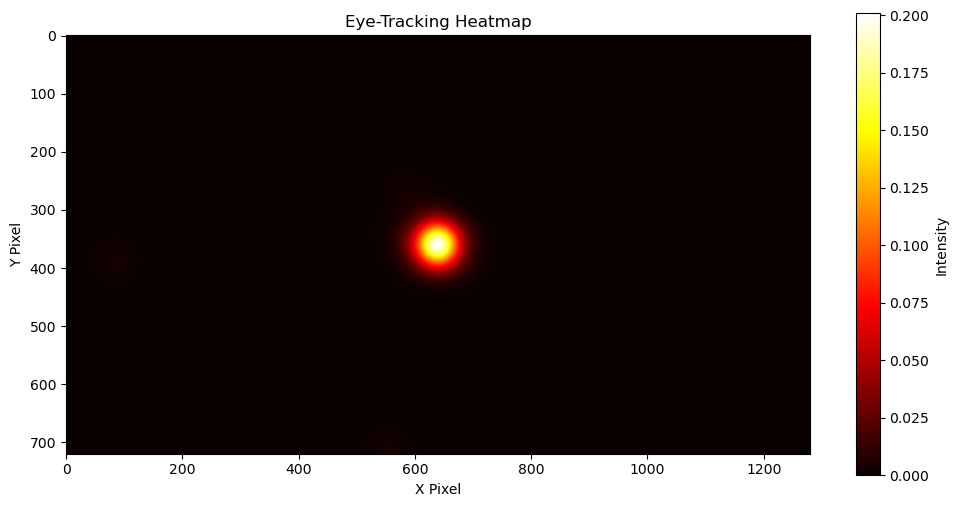

In [26]:
plt.figure(figsize=(12, 6))
plt.imshow(data_items[1], cmap='hot')
plt.title('Eye-Tracking Heatmap')
plt.colorbar(label='Intensity')
plt.xlabel('X Pixel')
plt.ylabel('Y Pixel')
plt.show()

Prepping data for PCA       

In [44]:
import pickle as pkl 
import pandas as pd 


file_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\1.2.3_kinect_sep_09.pkl" 

with open(file_path, 'rb') as f: 
    data = pkl.load(f)
print(data)
df = pd.DataFrame(data['combined_resampled_df'])
# print(len(pd.DataFrame(data['appear_post'])))
print("length of objhand dict", len(pd.DataFrame(data['objhand_post']))) #same length of objhand df as used for the aligned df 
print("length of the current resampled df with objhand vectors", len(df))

{'skel_post':        J0_dist_from_J1  J0_speed  J0_acceleration  J1_speed  J1_acceleration  \
frame                                                                          
91                 NaN       NaN              NaN       NaN              NaN   
92                 NaN       NaN              NaN       NaN              NaN   
93                 NaN       NaN              NaN       NaN              NaN   
94                 NaN       NaN              NaN       NaN              NaN   
95                 NaN       NaN              NaN       NaN              NaN   
...                ...       ...              ...       ...              ...   
14589        -1.579637  2.877439          2.65342  3.202544         0.001404   
14590        -1.420320  2.877439          2.65342  3.202544         0.001404   
14591        -2.162512  2.877439          2.65342  3.202544         0.001404   
14592        -2.162512  2.877439          2.65342  3.202544         0.001404   
14593        -2.162512  2.

In [40]:
vid_1_aligned = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\1.2.3_aligned_hand_attention.csv" 
vid_1_attend_full = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\1.2.3_C1_scene_vectors.csv"

scene_attend_full = pd.read_csv(vid_1_attend_full)
scene_df = pd.read_csv(vid_1_aligned) 

attention_columns = [col for col in scene_df.columns if col.startswith("attention_")] 
print(attention_columns)
attention_frames = scene_df[attention_columns] #now i have a dataframe of all of the attention vectors 
print(attention_frames)
print(len(attention_frames))

objhand_columns = [col for col in scene_df.columns if col.startswith("objhand_")]
objhand_df = scene_df[objhand_columns] 
print(len(objhand_df))



['attention_1', 'attention_2', 'attention_3', 'attention_4', 'attention_5', 'attention_6', 'attention_7', 'attention_8', 'attention_9', 'attention_10', 'attention_11', 'attention_12', 'attention_13', 'attention_14', 'attention_15', 'attention_16', 'attention_17', 'attention_18', 'attention_19', 'attention_20', 'attention_21', 'attention_22', 'attention_23', 'attention_24', 'attention_25', 'attention_26', 'attention_27', 'attention_28', 'attention_29', 'attention_30', 'attention_31', 'attention_32', 'attention_33', 'attention_34', 'attention_35', 'attention_36', 'attention_37', 'attention_38', 'attention_39', 'attention_40', 'attention_41', 'attention_42', 'attention_43', 'attention_44', 'attention_45', 'attention_46', 'attention_47', 'attention_48', 'attention_49', 'attention_50']
       attention_1  attention_2  attention_3  attention_4  attention_5  \
0              NaN          NaN          NaN          NaN          NaN   
1              NaN          NaN          NaN          NaN   

In [6]:
print(df.columns)
print(data)

Index(['appear', 'disappear', 'optical_flow_avg', 'pixel_correlation',
       'J0_dist_from_J1', 'J0_speed', 'J0_acceleration', 'J1_speed',
       'J1_acceleration', 'J2_dist_from_J1',
       ...
       'scene_40', 'scene_41', 'scene_42', 'scene_43', 'scene_44', 'scene_45',
       'scene_46', 'scene_47', 'scene_48', 'scene_49'],
      dtype='object', length=253)
{'skel_post':        J0_dist_from_J1  J0_speed  J0_acceleration  J1_speed  J1_acceleration  \
frame                                                                          
91                 NaN       NaN              NaN       NaN              NaN   
92                 NaN       NaN              NaN       NaN              NaN   
93                 NaN       NaN              NaN       NaN              NaN   
94                 NaN       NaN              NaN       NaN              NaN   
95                 NaN       NaN              NaN       NaN              NaN   
...                ...       ...              ...       ...  

In [45]:
import pandas as pd 
list_features = ['appear_post', 'optical_post','skel_post']
list_df = []
for name in list_features: 
    data_features = data[name] 
    print(f"This is the {name} data_features", data_features)
    data_df = pd.DataFrame(data_features)
    list_df.append(data_df)

list_df.append(attention_frames)
list_df.append(pd.DataFrame(data['scene_post']))
print(list_df)

This is the appear_post data_features        appear  disappear
frame                   
0         7.0        0.0
1         0.0        0.0
2         0.0        0.0
3         0.0        0.0
4         0.0        0.0
...       ...        ...
14621     0.0        0.0
14622     0.0        0.0
14623     0.0        0.0
14624     0.0        0.0
14625     0.0        1.0

[14626 rows x 2 columns]
This is the optical_post data_features        optical_flow_avg  pixel_correlation
frame                                     
10            -0.774810          -0.654144
20            -0.714995          -0.651385
30            -0.734261          -0.652051
40            -0.672202          -0.647070
50            -0.688003          -0.647749
...                 ...                ...
14580          1.286041           1.719609
14590          2.009526           3.769848
14600          1.340910           2.290766
14610          0.790311           0.745365
14620         -0.606549          -0.611315

[1462 rows x

In [46]:
import math 

def interpolate_frame(dataframe: pd.DataFrame) -> pd.DataFrame:
    first_frame = int(dataframe.index[0])
    last_frame = int(dataframe.index[-1])
    dummy_frame = pd.DataFrame(np.NaN, index=range(first_frame, last_frame),
                               columns=dataframe.columns)
    dummy_frame = dummy_frame.combine_first(dataframe).interpolate(limit_area='inside')
    return dummy_frame



def resample_df(df, fps, rate) -> pd.DataFrame:
     # fps matter hear, we need feature vector at anchor timepoints to correspond to segmentation
            out_df = df.set_index(pd.to_datetime(df.index / fps, unit='s'), drop=False, verify_integrity=True)
            # dummy_frame is necessary in case df has missing frames and needs interpolation
            # though, df was already interpolated before in combine_data_frames and even after -> TODO: remove dummy_frame
            resample_index = pd.date_range(start=out_df.index[0], end=out_df.index[-1], freq=rate)
            dummy_frame = pd.DataFrame(np.NaN, index=resample_index, columns=out_df.columns)
            # resample().mean() will make frame_id not integer anymore
            out_df = out_df.combine_first(dummy_frame).interpolate(method='time', limit_area='inside').resample(rate).mean()
            return out_df

def combine_dataframes(data_frames, fps, rate) -> pd.DataFrame:
        # Some features such as optical flow are calculated not for all frames, interpolate first
        pd.set_option('use_inf_as_na', True)
        data_frames = [interpolate_frame(df) for df in data_frames]
        combine_df = pd.concat(data_frames, axis=1)
        # After dropping null values, variances are not unit anymore, some are around 0.8.
        combine_df.dropna(axis=0, inplace=True)
        combine_df['frame'] = combine_df.index
        # After resampling, some variances drop to 0.3 or 0.4
        combine_df = resample_df(combine_df,fps,rate)
        # because resample use mean, need to adjust categorical variables
        combine_df['appear'] = combine_df['appear'].apply(math.ceil).astype(float)
        combine_df['disappear'] = combine_df['disappear'].apply(math.ceil).astype(float)

        # assert combine_df.isna().sum().sum() == 0
        combine_df.set_index('frame', inplace=True)
        combine_df.drop(['sync_time', 'frame'], axis=1, inplace=True, errors='ignore')
        return combine_df

In [50]:
import numpy as np 
resampled_combined_df = combine_dataframes(list_df, 25, "333ms")
# print(resampled_combined_df.iloc[:, :2])
print(resampled_combined_df.columns)

Index(['appear', 'disappear', 'optical_flow_avg', 'pixel_correlation',
       'J0_dist_from_J1', 'J0_speed', 'J0_acceleration', 'J1_speed',
       'J1_acceleration', 'J2_dist_from_J1',
       ...
       'scene_40', 'scene_41', 'scene_42', 'scene_43', 'scene_44', 'scene_45',
       'scene_46', 'scene_47', 'scene_48', 'scene_49'],
      dtype='object', length=253)


In [61]:
import pickle as pkl
import pandas as pd
import numpy as np
import math
import os

def interpolate_frame(dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Interpolate missing frames between the first and last frame.
    Assumes the DataFrame is indexed by integer frame numbers.
    """
    first_frame = int(dataframe.index[0])
    last_frame = int(dataframe.index[-1])
    print("this is the last frame",last_frame)
    dummy_frame = pd.DataFrame(np.NaN, index=range(first_frame, last_frame), columns=dataframe.columns)
    dummy_frame = dummy_frame.combine_first(dataframe).interpolate(limit_area='inside')
    return dummy_frame

def resample_df(df, fps, rate) -> pd.DataFrame:
    """
    Resample the DataFrame in time using the given frames per second (fps) and resampling rate.
    The index of df is assumed to be frame numbers.
    """
    # Convert the frame index (which are numbers) to a datetime index using fps.
    out_df = df.set_index(pd.to_datetime(df.index / fps, unit='s'), drop=False, verify_integrity=True)
    resample_index = pd.date_range(start=out_df.index[0], end=out_df.index[-1], freq=rate)
    dummy_frame = pd.DataFrame(np.NaN, index=resample_index, columns=out_df.columns)
    out_df = out_df.combine_first(dummy_frame).interpolate(method='time', limit_area='inside').resample(rate).mean()
    return out_df

def combine_dataframes(data_frames, fps, rate) -> pd.DataFrame:
    """
    Given a list of DataFrames (each indexed by frame number), interpolate and concatenate them,
    drop any remaining missing frames, add a 'frame' column, and then resample the combined DataFrame.
    """
    pd.set_option('use_inf_as_na', True)
    data_frames = [interpolate_frame(df) for df in data_frames]
    combine_df = pd.concat(data_frames, axis=1) 
    print("length of dataframes right after interpolation:", len(combine_df))
   
    combine_df.dropna(axis=0, inplace=True)
 
    combine_df['frame'] = combine_df.index
    combine_df = resample_df(combine_df, fps, rate)
    print("length of dataframe right after resampling:", len(combine_df))
    
    combine_df['appear'] = combine_df['appear'].apply(math.ceil).astype(float)
    combine_df['disappear'] = combine_df['disappear'].apply(math.ceil).astype(float)
    # assert combine_df.isna().sum().sum() == 0

    combine_df.set_index('frame', inplace=True)
    combine_df.drop(['sync_time', 'frame'], axis=1, inplace=True, errors='ignore')
    return combine_df


input_pkl_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\6.3.9_kinect_sep_09.pkl"


attention_csv_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\scene_embs\6.3.9_aligned_hand_attention.csv"


output_pkl_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\6.3.9_kinect_sep_09_attention.pkl"


with open(input_pkl_path, "rb") as f:
    data = pkl.load(f)

print("Original resampled dataframe with objhand length:", len(data['combined_resampled_df']))
print("length of objhand_post", len(data['objhand_post']))
required_keys = ['appear_post', 'optical_post', 'skel_post', 'scene_post']
appear_post = pd.DataFrame(data['appear_post'])
print("Length of appear post preprocess:", len(appear_post))
optical_post = pd.DataFrame(data['optical_post'])
skel_post = pd.DataFrame(data['skel_post'])
scene_post = pd.DataFrame(data['scene_post'])


attention_df = pd.read_csv(attention_csv_path) #aligned attention with hand values 

attention_cols = [col for col in attention_df.columns if col.startswith("attention_")]
attention_post = attention_df[attention_cols]
print("length of attention_post", len(attention_post))
post_features_list = [appear_post, optical_post, skel_post,  attention_post, scene_post]
fps = 25
rate = "333ms"
combined_resampled_df = combine_dataframes(post_features_list, fps, rate)

data['combined_resampled_df'] = combined_resampled_df
print("Length of combined resampled_df with attention:", len(combined_resampled_df))
with open(output_pkl_path, "wb") as f:
    pkl.dump(data, f)

print("New pickle file created:")
print(f"  - Combined resampled features at key 'combined_resampled_df'")
print(f"  - Original _post features for each modality preserved (e.g., 'appear_post', etc.)")
print("Output path:", output_pkl_path)

Original resampled dataframe with objhand length: 1988
length of objhand_post 16844
Length of appear post preprocess: 16751
length of attention_post 16844
this is the last frame 16750
this is the last frame 16960
this is the last frame 16843
this is the last frame 16843
this is the last frame 16843
length of dataframes right after interpolation: 16961
length of dataframe right after resampling: 1988
Length of combined resampled_df with attention: 1988
New pickle file created:
  - Combined resampled features at key 'combined_resampled_df'
  - Original _post features for each modality preserved (e.g., 'appear_post', etc.)
Output path: C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\6.3.9_kinect_sep_09_attention.pkl


In [59]:
import pickle as pkl 

resampled_attention_pkl_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\3.1.3_kinect_sep_09_attention.pkl"
with open(resampled_attention_pkl_path, "rb") as f:
    data_attend = pkl.load(f)
print(len(data_attend['combined_resampled_df']))
print(data_attend['combined_resampled_df'].tail(n=25))

1695
              appear  disappear  optical_flow_avg  pixel_correlation  \
frame                                                                  
14039.775000     1.0        0.0         -0.543254          -0.403873   
14048.230556     0.0        0.0         -0.511042          -0.375706   
14056.266667     0.0        0.0         -0.487786          -0.359399   
14064.772500     0.0        0.0         -0.419444          -0.339922   
14073.227778     0.0        0.0         -0.316193          -0.267122   
14081.263889     0.0        0.0         -0.229546          -0.136824   
14089.770000     0.0        0.0         -0.195798          -0.071590   
14098.225000     0.0        0.0         -0.274529          -0.145113   
14106.261111     0.0        0.0         -0.414805          -0.290913   
14114.767500     1.0        0.0         -0.491302          -0.368236   
14123.500000     0.0        0.0         -0.427141          -0.333106   
14131.258333     0.0        0.0         -0.261318          

In [60]:
input_pkl_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\preprocessed_features\3.1.3_kinect_sep_09.pkl"
with open(input_pkl_path, "rb") as f:
    data_hand = pkl.load(f)

print(len(data_hand['combined_resampled_df']))
print(data_hand['combined_resampled_df'].tail(n=25))


1695
              appear  disappear  optical_flow_avg  pixel_correlation  \
frame                                                                  
14039.775000     1.0        0.0         -0.543254          -0.403873   
14048.230556     0.0        0.0         -0.511042          -0.375706   
14056.266667     0.0        0.0         -0.487786          -0.359399   
14064.772500     0.0        0.0         -0.419444          -0.339922   
14073.227778     0.0        0.0         -0.316193          -0.267122   
14081.263889     0.0        0.0         -0.229546          -0.136824   
14089.770000     0.0        0.0         -0.195798          -0.071590   
14098.225000     0.0        0.0         -0.274529          -0.145113   
14106.261111     0.0        0.0         -0.414805          -0.290913   
14114.767500     1.0        0.0         -0.491302          -0.368236   
14123.500000     0.0        0.0         -0.427141          -0.333106   
14131.258333     0.0        0.0         -0.261318          

In [4]:
objhand_columns = [col for col in scene_df.columns if col.startswith("objhand_")] 
objhand_df = df[objhand_columns]
print(objhand_df)
print(len(objhand_df))

              objhand_0  objhand_1  objhand_2  objhand_3  objhand_4  \
frame                                                                 
154.000000    -0.030958   0.116277  -0.456158  -0.126465   0.145298   
162.036111    -0.293743  -0.024142  -0.433338   0.014818   0.098529   
170.072222    -0.329725  -0.025495  -0.428394  -0.026642   0.078069   
178.597500    -0.406928  -0.035517  -0.396207  -0.179384   0.020586   
187.033333    -0.406727  -0.035891  -0.395647  -0.179993   0.020812   
...                 ...        ...        ...        ...        ...   
14547.592500  -0.525840   0.182340  -0.576424  -0.008214   0.254566   
14556.027778  -0.649815   0.154651  -0.466268  -0.099938   0.325400   
14564.063889  -0.810402   0.124339  -0.335575  -0.206227   0.390733   
14572.590000  -0.812497   0.126571  -0.334688  -0.207811   0.390926   
14579.045000  -0.804713   0.128546  -0.338483  -0.206096   0.394207   

              objhand_5  objhand_6  objhand_7  objhand_8  objhand_9  ...  \


In [1]:
import pickle as pkl 

file_path_pca = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output\sep_09_all_appear_pca.pkl" 
with open(file_path_pca, 'rb') as f: 
    data = pkl.load(f) 

print(data)

PCA(n_components=2, whiten=True)


c:\Users\super\anaconda3\envs\sem-viz-jupyter\lib\site-packages\sklearn\base.py:338: UserWarning: Trying to unpickle estimator PCA from version 0.23.2 when using version 1.0.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/modules/model_persistence.html#security-maintainability-limitations
  UserWarning,


In [8]:
import itertools 
start_train_list = ['1.2.3_kinect', '2.4.1_kinect', '3.1.3_kinect', '6.3.9_kinect'] 
val_639_permuts = list(itertools.permutations(start_train_list[:-1]))
print(len(val_639_permuts))

6


In [ ]:
from pathlib import Path 
import os 
from collections import deque 

direct_path = r"C:\Users\super\OneDrive\Desktop\Github repos\extended-event-modeling\output"

val_nums = ['6.3.9', '3.1.3', '2.4.1', '1.2.3']
start_train_list = ['1.2.3_kinect', '2.4.1_kinect', '3.1.3_kinect', '6.3.9_kinect']
dq = deque(start_train_list) 
for num in val_nums:   
  start_train_list = list(dq)
  file_name = "train_val" + str(num) + ".txt" #this just creates a file apparently 
  file_path_train = os.path.join(direct_path, file_name) 
  file_name_val = "val" + str(num) + ".txt" 
  file_path_val = os.path.join(direct_path, file_name_val) 
  with open(file_path_train, 'w') as f: 
    for start_train in start_train_list[:-1]: 
      f.write(start_train + "\n")
  with open(file_path_val, 'w') as f: 
      f.write(start_train_list[-1] + "\n")
  dq.rotate(1)
  print(start_train_list)



['1.2.3_kinect', '2.4.1_kinect', '3.1.3_kinect', '6.3.9_kinect']
['6.3.9_kinect', '1.2.3_kinect', '2.4.1_kinect', '3.1.3_kinect']
['3.1.3_kinect', '6.3.9_kinect', '1.2.3_kinect', '2.4.1_kinect']
['2.4.1_kinect', '3.1.3_kinect', '6.3.9_kinect', '1.2.3_kinect']


In [9]:
import itertools
import os
from pathlib import Path


start_train_list = ['1.2.3_kinect', '2.4.1_kinect', '3.1.3_kinect', '6.3.9_kinect']
output_dir = Path("../../output")
output_dir.mkdir(exist_ok=True)

for val_video in start_train_list:
    val_id = val_video.split('_')[0]
    
    val_filename = f"val{val_id}.txt"
    val_path = output_dir / val_filename
    with open(val_path, 'w') as f: #create a file with the validation video 
        f.write(f"{val_video}\n")
    
    train_videos = [v for v in start_train_list if v != val_video]
    
    permutations = list(itertools.permutations(train_videos))
    
    for perm_num, perm in enumerate(permutations, 1):
        train_filename = f"trainval{val_id}_permutation_{perm_num}.txt"
        train_path = output_dir / train_filename
        
        with open(train_path, 'w') as f:
            for video in perm:
                f.write(f"{video}\n")
        
        print(f"Created {train_filename} with permutation {perm} and {val_filename} with {val_video}")

print(f"Generated {len(start_train_list) * len(list(itertools.permutations(start_train_list[:-1])))} training/validation file pairs.")

Created trainval1.2.3_permutation_1.txt with permutation ('2.4.1_kinect', '3.1.3_kinect', '6.3.9_kinect') and val1.2.3.txt with 1.2.3_kinect
Created trainval1.2.3_permutation_2.txt with permutation ('2.4.1_kinect', '6.3.9_kinect', '3.1.3_kinect') and val1.2.3.txt with 1.2.3_kinect
Created trainval1.2.3_permutation_3.txt with permutation ('3.1.3_kinect', '2.4.1_kinect', '6.3.9_kinect') and val1.2.3.txt with 1.2.3_kinect
Created trainval1.2.3_permutation_4.txt with permutation ('3.1.3_kinect', '6.3.9_kinect', '2.4.1_kinect') and val1.2.3.txt with 1.2.3_kinect
Created trainval1.2.3_permutation_5.txt with permutation ('6.3.9_kinect', '2.4.1_kinect', '3.1.3_kinect') and val1.2.3.txt with 1.2.3_kinect
Created trainval1.2.3_permutation_6.txt with permutation ('6.3.9_kinect', '3.1.3_kinect', '2.4.1_kinect') and val1.2.3.txt with 1.2.3_kinect
Created trainval2.4.1_permutation_1.txt with permutation ('1.2.3_kinect', '3.1.3_kinect', '6.3.9_kinect') and val2.4.1.txt with 2.4.1_kinect
Created train